In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv("../assets/csv-files/churn-modelling.csv")
dataset.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [4]:
# Drop columns with object (string) type data
dataset = dataset.select_dtypes(exclude=["object"])
dataset.head(3)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,619,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,608,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,502,42,8,159660.80,3,1,0,113931.57,1


In [5]:
# Check for null values
dataset.isnull().sum() # No null values

RowNumber          0
CustomerId         0
CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
# Seperate input and output data
input_data = dataset.iloc[:, :-1]
output_data = dataset.iloc[:, -1]

In [7]:
# Scaling the input data
from sklearn.preprocessing import StandardScaler

In [8]:
ss = StandardScaler()
input_data = pd.DataFrame(ss.fit_transform(input_data), columns=input_data.columns)

In [9]:
# Train test split
from sklearn.model_selection import train_test_split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=12)

In [11]:
# Create an artificial neural network
import tensorflow
from keras.layers import Dense
from keras.models import Sequential

In [12]:
ann = Sequential() # Object initialization

In [13]:
# Check the shape of training data
print(x_train.shape, y_train.shape)  # Ensure shapes are correct

(8000, 10) (8000,)


In [14]:
# Build different layers
ann.add(Dense(8, input_dim=x_train.shape[1], activation="relu"))  # First hidden layer
# First parameter 8 is the number of nodes in the layer
ann.add(Dense(6, activation="relu"))  # Second hidden layer
ann.add(Dense(4, activation="relu"))  # Third hidden layer
ann.add(Dense(2, activation="relu"))  # Fourth hidden layer
ann.add(Dense(1, activation="sigmoid"))  # Output layer


C:\Users\kusha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Compile the model
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [16]:
# Train the model
ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test))
# Validation data is for testing accuracy

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5337 - loss: 0.7006 - val_accuracy: 0.7815 - val_loss: 0.6723
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8004 - loss: 0.6657 - val_accuracy: 0.7825 - val_loss: 0.6531
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8013 - loss: 0.6455 - val_accuracy: 0.7820 - val_loss: 0.6361
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8081 - loss: 0.6259 - val_accuracy: 0.7820 - val_loss: 0.6207
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8023 - loss: 0.6110 - val_accuracy: 0.7820 - val_loss: 0.6071
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7973 - loss: 0.5984 - val_accuracy: 0.7820 - val_loss: 0.5949
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8030 - loss: 0.5830 - val_accuracy: 0.7825 - val_loss: 0.5835
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7999 - loss: 0.5726 - val_accuracy: 0.7870 - val_loss:

In [707]:
# View training history
ann.history.history
# The history attribute of a Keras model contains the training history, including metrics like loss and accuracy for each epoch.

{'accuracy': [0.799875020980835,
  0.799875020980835,
  0.799875020980835,
  0.799875020980835,
  0.799875020980835,
  0.799875020980835,
  0.799875020980835,
  0.799875020980835,
  0.799875020980835,
  0.799875020980835,
  0.799875020980835,
  0.8153749704360962,
  0.8215000033378601,
  0.8227499723434448,
  0.8242499828338623,
  0.8245000243186951,
  0.8243749737739563,
  0.8262500166893005,
  0.8330000042915344,
  0.8379999995231628,
  0.843874990940094,
  0.8456249833106995,
  0.8466249704360962,
  0.8506249785423279,
  0.8510000109672546,
  0.8525000214576721,
  0.8522499799728394,
  0.8533750176429749,
  0.8539999723434448,
  0.8541250228881836,
  0.8547499775886536,
  0.8556249737739563,
  0.8556249737739563,
  0.8544999957084656,
  0.856124997138977,
  0.8557500243186951,
  0.8558750152587891,
  0.8565000295639038,
  0.8560000061988831,
  0.8566250205039978,
  0.856249988079071,
  0.8554999828338623,
  0.8566250205039978,
  0.856249988079071,
  0.8567500114440918,
  0.856249988

In [17]:
# To get all the keys of history
ann.history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [18]:
# To see specific values of keys
ann.history.history["accuracy"] # For accuracy

[0.6728749871253967,
 0.7994999885559082,
 0.799875020980835,
 0.799875020980835,
 0.799875020980835,
 0.799875020980835,
 0.800125002861023,
 0.8008750081062317,
 0.8036249876022339,
 0.809499979019165,
 0.8174999952316284,
 0.8243749737739563,
 0.827750027179718,
 0.8291249871253967,
 0.8298749923706055,
 0.8302500247955322,
 0.8299999833106995,
 0.8308749794960022,
 0.8318750262260437,
 0.8317499756813049,
 0.8314999938011169,
 0.8321250081062317,
 0.8323749899864197,
 0.8318750262260437,
 0.831250011920929,
 0.8323749899864197,
 0.8309999704360962,
 0.8320000171661377,
 0.8324999809265137,
 0.8326249718666077,
 0.8382499814033508,
 0.8392500281333923,
 0.8448749780654907,
 0.8471249938011169,
 0.8514999747276306,
 0.8525000214576721,
 0.8523749709129333,
 0.8527500033378601,
 0.8528749942779541,
 0.8537499904632568,
 0.8533750176429749,
 0.8544999957084656,
 0.8537499904632568,
 0.8548750281333923,
 0.8543750047683716,
 0.8551250100135803,
 0.8558750152587891,
 0.8544999957084656,


In [19]:
# To get training and testing accuracy of each epoch
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]

In [20]:
# Visualize the accuracy
# Get the lengths of accuracies for plotting
len(test_accuracy), len(train_accuracy) 

(50, 50)

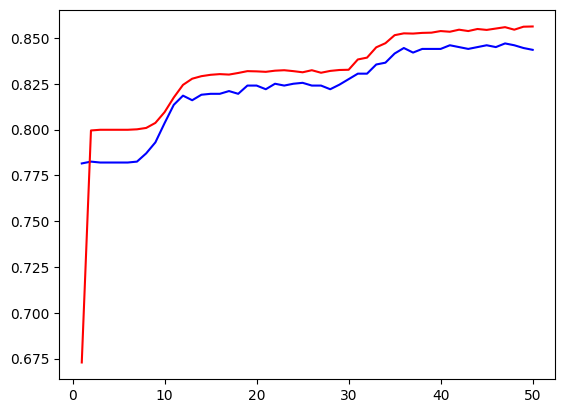

In [21]:
# Draw graph
plt.plot([i+1 for i in range(len(test_accuracy))], test_accuracy, color="blue")
plt.plot([i+1 for i in range(len(train_accuracy))], train_accuracy, color="red")
plt.show()

In [22]:
# Check the accuracy of our model
from sklearn.metrics import accuracy_score

In [23]:
# Predictions of x_train
predict_x_train = ann.predict(x_train)
x_train_predictions = []
for i in predict_x_train:
    if i[0] > 0.5:
        x_train_predictions.append(1)
    else:
        x_train_predictions.append(0)
# View predictions
x_train_predictions

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


[0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,


In [24]:
# Predictions of x_test
predict_x_test = ann.predict(x_test)
x_test_predictions = []
for i in predict_x_test:
    if i[0] > 0.5:
        x_test_predictions.append(1)
    else:
        x_test_predictions.append(0)
# View predictions
x_test_predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


[0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,


In [25]:
# Get accuracy
train_data_accuracy = accuracy_score(y_train, x_train_predictions) * 100 
test_data_accuracy = accuracy_score(y_test, x_test_predictions) * 100
train_data_accuracy, test_data_accuracy

(85.8, 84.35000000000001)

In [26]:
"""If the training accuracy is more than testing accuracy, the model is overfitted.
To avoid overfitting we use various techniques like Early Stopping and Regularization.
These methods helps in minimizing the gaps between the accuracies."""

'If the training accuracy is more than testing accuracy, the model is overfitted.\nTo avoid overfitting we use various techniques like Early Stopping and Regularization.\nThese methods helps in minimizing the gaps between the accuracies.'

#### Early Stopping

In [27]:
from keras.callbacks import EarlyStopping

In [28]:
# Train the model
ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test), callbacks=EarlyStopping())
# EarlyStopping stops the training if epoch is going toward overfitting


Epoch 1/50


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8578 - loss: 0.3887 - val_accuracy: 0.8455 - val_loss: 0.4054
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8558 - loss: 0.3908 - val_accuracy: 0.8450 - val_loss: 0.4037
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8559 - loss: 0.3935 - val_accuracy: 0.8460 - val_loss: 0.4041


In [29]:
# To get training and testing accuracy
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]

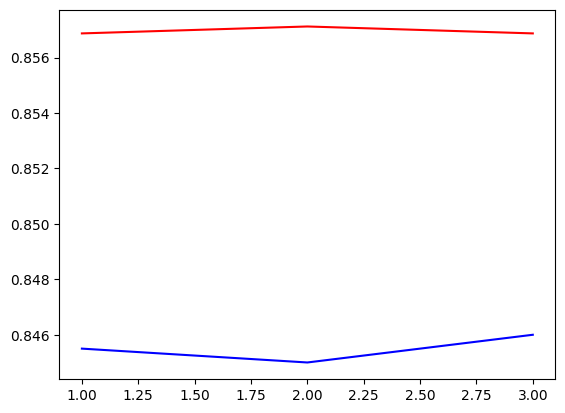

In [30]:
# Visualize the accuracy
plt.plot([i+1 for i in range(len(test_accuracy))], test_accuracy, color="blue")
plt.plot([i+1 for i in range(len(train_accuracy))], train_accuracy, color="red")
plt.show()

#### Regularization

In [31]:
from keras.regularizers import L2

In [32]:
# Build different layers
ann.add(Dense(8, input_dim=x_train.shape[1], activation="relu",  kernel_regularizer=L2(l2=0.01)))
# kernel_regularizer stops the training if it is going towards overfitting using given regularization technique
ann.add(Dense(6, activation="relu", kernel_regularizer=L2(l2=0.01)))
# kernel_reqularizer can be used in different layers differently if you want or you can simply skip as below
ann.add(Dense(4, activation="relu"))  
ann.add(Dense(2, activation="relu"))  
ann.add(Dense(1, activation="sigmoid")) 

C:\Users\kusha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# Compile the model
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [34]:
# Train the model
ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test))


Epoch 1/50


80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7827 - loss: 0.7636 - val_accuracy: 0.8450 - val_loss: 0.7282
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8561 - loss: 0.7162 - val_accuracy: 0.8470 - val_loss: 0.6873
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8440 - loss: 0.6782 - val_accuracy: 0.8455 - val_loss: 0.6495
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8633 - loss: 0.6379 - val_accuracy: 0.8475 - val_loss: 0.6146
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8553 - loss: 0.6075 - val_accuracy: 0.8485 - val_loss: 0.5871
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8648 - loss: 0.5784 - val_accuracy: 0.8490 - val_loss: 0.5655
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8535 - loss: 0.5607 - val_accuracy: 0.8470 - val_loss: 0.5475
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8613 - loss: 0.5389 - val_accuracy: 0.8495 - val_loss: 0.5328
Epo

In [35]:
# To get training and testing accuracy
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]
train_accuracy, test_accuracy

([0.8367499709129333,
  0.8529999852180481,
  0.8556249737739563,
  0.8554999828338623,
  0.8567500114440918,
  0.8586249947547913,
  0.8588749766349792,
  0.859250009059906,
  0.859499990940094,
  0.8603749871253967,
  0.859250009059906,
  0.8606250286102295,
  0.859624981880188,
  0.8618749976158142,
  0.8613749742507935,
  0.8606250286102295,
  0.8606250286102295,
  0.8612499833106995,
  0.8607500195503235,
  0.8612499833106995,
  0.859749972820282,
  0.8604999780654907,
  0.8601250052452087,
  0.8600000143051147,
  0.859749972820282,
  0.8619999885559082,
  0.8608750104904175,
  0.8607500195503235,
  0.8603749871253967,
  0.8611249923706055,
  0.859499990940094,
  0.8606250286102295,
  0.8606250286102295,
  0.8610000014305115,
  0.8607500195503235,
  0.8617500066757202,
  0.8608750104904175,
  0.8608750104904175,
  0.8613749742507935,
  0.862625002861023,
  0.8606250286102295,
  0.8619999885559082,
  0.8618749976158142,
  0.8611249923706055,
  0.8598750233650208,
  0.86212497949600

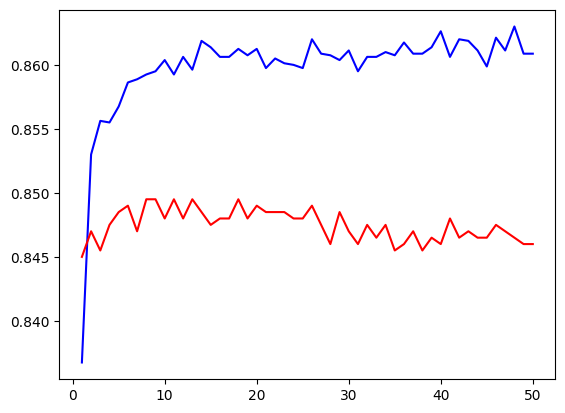

In [36]:
# Visualize the accuracy
plt.plot([i+1 for i in range(len(test_accuracy))], train_accuracy, color="blue")
plt.plot([i+1 for i in range(len(train_accuracy))], test_accuracy, color="red")
plt.show()